# VisionVoice - Part 3: Attention ResNet-LSTM

This notebook runs the same data pipeline and trains the refined attention model. It finishes with BLEU evaluation and attention heatmap visualizations for qualitative inspection.

# 2. Initialization


## 2.1 Environment Setup and Logging

In [1]:
import os
import platform
import sys

print(f'Python : {sys.version}')
print(f'OS     : {platform.system()} {platform.release()}')
print(f'CWD    : {os.getcwd()}')

Python : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
OS     : Linux 6.6.122+
CWD    : /kaggle/working


## 2.2 Libraries

Modern Deep Learning relies on a robust ecosystem of libraries. We utilize **PyTorch** for computational graphs and tensor operations, **NumPy** for numerical processing, and **Pandas** for structured data manipulation. We also implement a **Warning Filter** to suppress non-critical engine warnings, ensuring that our final notebook remains professional and readable for peer review or production handover.

In [2]:
# Standard Python Utilities
import os, sys, gc, time, json, random, zipfile, warnings, shutil
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Iterable, Any
from collections import Counter

# Networking
import requests

# Data Processing
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Image Processing
from PIL import Image, UnidentifiedImageError

# Visualization
import matplotlib.pyplot as plt

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.models as models
import torchvision.transforms as transforms

# NLP & Progress
import nltk
from nltk.translate.bleu_score import corpus_bleu
from tqdm import tqdm

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings('ignore')

# Centralized Device Configuration
# This ensures we have a single source of truth for hardware acceleration
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Python       : {sys.version.split()[0]}")
print(f"PyTorch      : {torch.__version__}")
print(f"Target Device: {DEVICE}")

Python       : 3.12.12
PyTorch      : 2.10.0+cu128
Target Device: cuda


## 2.3 Centralized Configuration (Settings)

A best practice in high-level Data Science is the **Singleton Configuration Pattern**. Instead of hardcoding hyperparameters like 'LEARNING_RATE' or 'BATCH_SIZE' inside functions, we centralize them in a `Settings` class. This facilitates **Hyperparameter Optimization (HPO)** and makes switching between 'train' and 'inference' modes seamless. We use `pathlib` for **Object-Oriented Filesystem Paths**, which is more robust than standard string manipulation.

In [3]:
class Settings:
    """Centralized configuration class for the Image Captioning project.

    Contains all hyperparameters, environment settings, and dynamic path
    routing for both Kaggle and local VS Code environments.
    """

    # 1. Operational Toggles
    MODE: str = "train"   # "eda", "train", or "inference"
    DEBUG: bool = False
    DEBUG_SAMPLE_SIZE: int = 50 # Number of files to audit when DEBUG is True
    SHOW_EDA_PLOTS: bool = MODE == "eda"  # Dataset/EDA figures
    SHOW_MODEL_PLOTS: bool = MODE in {"train", "inference"}  # Post-training diagnostics

    # 2. Environment Detection
    IS_KAGGLE: bool = Path("/kaggle/input").exists()

    # 3. Dynamic Path Management
    # Override these in Kaggle with environment variables if your dataset slug changes:
    # VIZWIZ_DATA_DIR, VIZWIZ_ANNOTATIONS_DIR, VIZWIZ_IMAGE_DIR
    if IS_KAGGLE:
        DATA_DIR = Path(os.getenv("VIZWIZ_DATA_DIR", "/kaggle/input/datasets/tuannm3823/vizwiz"))
        ANNOTATIONS_DIR = Path(os.getenv("VIZWIZ_ANNOTATIONS_DIR", str(DATA_DIR / "annotations" / "annotations")))
        TRAIN_IMG_DIR = Path(os.getenv("VIZWIZ_IMAGE_DIR", str(DATA_DIR / "val" / "val")))
        VAL_IMG_DIR = TRAIN_IMG_DIR
        WORK_DIR = Path("/kaggle/working")
    else:
        try:
            from google.colab import drive
            drive.mount('/content/drive')
            DATA_DIR = Path(os.getenv("VIZWIZ_LOCAL_DATA_DIR", "/content/drive/MyDrive/Sem3_2026 Autumn/94691 Deep Learning/dl_assignments/dl_at3"))
        except ImportError:
            DATA_DIR = Path(os.getenv("VIZWIZ_LOCAL_DATA_DIR", "./data"))

        ANNOTATIONS_DIR = DATA_DIR / "annotations"
        TRAIN_IMG_DIR = DATA_DIR / "images"
        VAL_IMG_DIR = DATA_DIR / "images"
        WORK_DIR = DATA_DIR / "working"

    BASE: Path = DATA_DIR
    CACHE_DIR: Path = WORK_DIR / "cache"
    WORK_CACHE_DIR: Path = CACHE_DIR / "work"

    # /kaggle/input/models/tuannm3823/visionvoice-image-captioning/pytorch/attention-resnet-lstm/1/vision_voice_attention_best.pth
    # /kaggle/input/models/tuannm3823/visionvoice-image-captioning/pytorch/baseline-resnet-lstm/1/vision_voice_baseline_best.pth

    # 4. Remote Data URLs (For Section 3.1)
    URL_ANNOTATIONS: str = "https://vizwiz.cs.colorado.edu/VizWiz_final/annotations/val.json"
    URL_IMAGES: str = "https://vizwiz.cs.colorado.edu/VizWiz_final/images/val.zip"

    # 5. Data Processing & Pipeline Parameters
    SEED: int = 42
    VAL_SPLIT_SIZE: float = 0.2    # 20% of data used for validation
    VOCAB_MIN_FREQ: int = 2        # Minimum word occurrences to be indexed
    IMAGE_SIZE: int = 224          # ResNet standard input size
    NUM_WORKERS: int = 2           # DataLoader subprocesses

    # 6. Model Hyperparameters
    LEARNING_RATE: float = 1e-4
    BATCH_SIZE: int = 32
    EPOCHS: int = 10
    MAX_SEQ_LEN: int = 25          # Max words generated during inference
    EMBED_SIZE: int = 256          # Dimension of shared visual/textual space
    HIDDEN_SIZE: int = 512         # Number of units in LSTM hidden state
    NUM_LAYERS: int = 1            # Number of LSTM layers stacked
    MAX_GRAD_NORM: float = 5.0     # Clipping threshold for vanishing/exploding gradients

    # 7. Evaluation Parameters
    BLEU_EVAL_SAMPLES: int = 500   # Number of validation images to test for BLEU scoring

# Instantiate configuration object
CFG = Settings()

# Post-instantiation directory setup
CFG.CACHE_EXISTS = CFG.CACHE_DIR.exists()
CFG.WORK_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f'MODE         : {CFG.MODE}')
print(f'BASE         : {CFG.BASE}')
print(f'CACHE_EXISTS : {CFG.CACHE_EXISTS}')
print(f'CACHE_DIR    : {CFG.CACHE_DIR}')

MODE         : train
BASE         : /kaggle/input/datasets/tuannm3823/vizwiz
CACHE_EXISTS : True
CACHE_DIR    : /kaggle/working/cache


## 2.4 Memory Optimization and Management

Deep Learning models are notorious for **RAM/VRAM** exhaustion. To mitigate **Out-of-Memory (OOM)** errors and ensure smooth execution, we implement two critical strategies:
1.  **Garbage Collection**: Manually triggering `gc.collect()` and `torch.cuda.empty_cache()` to proactively free up unused memory pointers.
2.  **Data Type Downcasting**: The `reduce_mem_usage` function iterates through a **Pandas DataFrame** and intelligently converts data types to their smallest possible representation (e.g., `float64` to `float32` or `int64` to `int8`). This significantly reduces the memory footprint of large datasets without losing critical precision.

In [4]:
def clear_memory() -> None:
    """Forces garbage collection and clears VRAM cache to prevent OOM errors."""
    gc.collect()

    # Clear CUDA cache if using NVIDIA
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    # Clear MPS cache if using Apple Silicon
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()

    if CFG.DEBUG:
        print("[Memory] Garbage collection forced and accelerator cache cleared.")


def reduce_mem_usage(df: pd.DataFrame) -> pd.DataFrame:
    """
    Iterates through all columns of a dataframe and downcasts data types
    to their smallest possible representation to reduce memory footprint.
    """
    start_mem = df.memory_usage().sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtype

        # Exclude object (string) and categorical types from numeric downcasting
        if col_type != object and not pd.api.types.is_categorical_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2

    if CFG.DEBUG:
        reduction = 100 * (start_mem - end_mem) / start_mem
        print(f"[Memory] DataFrame compressed from {start_mem:.2f}MB to {end_mem:.2f}MB ({reduction:.1f}% reduction).")

    return df

## 2.5 Seeding

Deep learning is inherently **stochastic**. Weights are initialized randomly, and data is shuffled. To ensure that our performance metrics are comparable across different runs and by different team members, we must enforce **Global Determinism**. We do this by locking the seeds for the Python `random` module, `numpy`, and `torch`. Crucially, we also disable the **cuDNN benchmark** and set it to deterministic mode to ensure identical results on GPU backends.

In [5]:
def seed_everything(seed: int = CFG.SEED) -> None:
    """
    Locks all random number generators to a specific seed to ensure
    Global Determinism across independent experimental runs.
    """
    # 1. Python and Data structures
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # 2. NumPy
    np.random.seed(seed)

    # 3. PyTorch Core
    torch.manual_seed(seed)

    # 4. PyTorch CUDA (Hardware Acceleration)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) # Ensures determinism for multi-GPU setups

        # Enforce deterministic convolutions.
        # Note: This may slightly reduce training speed, but guarantees 100% reproducible results.
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    print(f"Global seed successfully locked to: {seed}")

# Execute initialization
seed_everything(CFG.SEED)

Global seed successfully locked to: 42


# 3. Data Preparing


## 3.1 Data Loading and Preparation

In modern **MLOps pipelines**, manual data handling is a significant bottleneck and a primary source of environment drift. To ensure **reproducibility** and scalability, we must automate the acquisition and initial preparation of our raw assets. The **VizWiz dataset** consists of high-resolution images and complex JSON annotations, which are often too large to fit entirely into system memory (RAM) during the download phase.

Our approach employs **chunked streaming** to download large ZIP files efficiently in small, manageable pieces (typically 8KB to 1MB). This prevents **Out-of-Memory (OOM)** errors during download. After downloading, the function automates the **extraction** of image and annotation files into their designated directories. This structured approach ensures that downstream preprocessing steps have a consistent and predictable data source, whether running on Kaggle or a local Colab environment.

In [6]:
def download_file(url: str, dest_dir: Path, filename: str = None) -> Path:
    """
    Downloads a file from a URL using chunked streaming to prevent OOM errors.

    Args:
        url (str): The source URL.
        dest_dir (Path): The local directory to save the file.
        filename (str, optional): Custom filename. Defaults to URL's trailing name.

    Returns:
        Path: The absolute path to the downloaded file.
    """
    dest_dir.mkdir(parents=True, exist_ok=True)
    filename = filename or url.split("/")[-1]
    file_path = dest_dir / filename

    if file_path.exists():
        print(f"[Network] '{filename}' already exists in cache. Skipping download.")
        return file_path

    print(f"[Network] Initiating stream for '{filename}'...")
    try:
        # Stream=True prevents loading the entire file into RAM at once
        with requests.get(url, stream=True, timeout=15) as response:
            response.raise_for_status()
            with open(file_path, "wb") as file:
                for chunk in response.iter_content(chunk_size=8192):
                    if chunk:
                        file.write(chunk)
        print(f"[Network] Successfully downloaded: {file_path}")
    except requests.exceptions.RequestException as e:
        print(f"[Error] Failed to download {filename}: {e}")
        raise SystemExit("Critical data missing. Pipeline halted.")

    return file_path

def prepare_dataset() -> None:
    """
    Orchestrates the data pipeline: routing Kaggle paths or downloading/extracting
    the VizWiz dataset into the local Colab environment.
    """
    if CFG.IS_KAGGLE:
        print("[Pipeline] Kaggle environment detected. Utilizing read-only mounted datasets.")
        if not (CFG.ANNOTATIONS_DIR / "val.json").exists():
             print(f"[Warning] val.json not found in {CFG.ANNOTATIONS_DIR}.")
        return

    print("--- Initializing Local Data Pipeline ---")

    # 1. Acquire Annotations (Metadata)
    CFG.ANNOTATIONS_DIR.mkdir(parents=True, exist_ok=True)
    download_file(
        url=CFG.URL_ANNOTATIONS,
        dest_dir=CFG.ANNOTATIONS_DIR,
        filename="val.json"
    )

    # 2. Acquire and Extract Images
    # We verify extraction success by checking if the directory exists and is populated
    if CFG.TRAIN_IMG_DIR.exists() and any(CFG.TRAIN_IMG_DIR.iterdir()):
        print(f"[Pipeline] Image payload verified at: {CFG.TRAIN_IMG_DIR}. Skipping extraction.")
    else:
        print(f"[Pipeline] Image directory empty. Beginning extraction protocol...")
        CFG.TRAIN_IMG_DIR.mkdir(parents=True, exist_ok=True)

        # Download the heavy zip file to the temporary cache
        zip_path = download_file(CFG.URL_IMAGES, CFG.WORK_CACHE_DIR)

        print(f"[Storage] Unpacking compressed images to {CFG.TRAIN_IMG_DIR}...")
        try:
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                # Extract to a temp cache folder to handle unexpected internal nested folders
                temp_extract_path = CFG.WORK_CACHE_DIR / "temp_extract"
                temp_extract_path.mkdir(exist_ok=True)
                zip_ref.extractall(temp_extract_path)

                # Flatten the directory structure if the zip contained a root 'val' folder
                extracted_items = list(temp_extract_path.iterdir())
                if len(extracted_items) == 1 and extracted_items[0].is_dir():
                    source_dir = extracted_items[0]
                else:
                    source_dir = temp_extract_path

                # Move files to final persistent directory
                for item in source_dir.iterdir():
                    shutil.move(str(item), str(CFG.TRAIN_IMG_DIR / item.name))

                # Housekeeping: Clean up temporary extraction folders
                shutil.rmtree(temp_extract_path)

            print("[Storage] Extraction and cleanup complete.")

        except zipfile.BadZipFile:
            print(f"[Error] Corrupted archive detected at {zip_path}.")
            zip_path.unlink() # Delete corrupted zip to force fresh download on next run
            raise SystemExit("Please re-run the cell to attempt download again.")

# Execute Pipeline
prepare_dataset()

[Pipeline] Kaggle environment detected. Utilizing read-only mounted datasets.


## 3.2 Parsing and Cleaning Annotations

In Vision-Language (VL) tasks, the bridge between visual features and linguistic tokens is the **Metadata Annotation**. The VizWiz dataset follows a relational JSON structure (similar to COCO) where image metadata and textual captions are stored in separate lists linked by unique identifiers.

In [7]:
print(f"--- Parsing Raw Annotations ---")
json_path = CFG.ANNOTATIONS_DIR / "val.json"

# 1. Load the Raw Data
with open(json_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

images_df = pd.DataFrame(data['images'])
annotations_df = pd.DataFrame(data['annotations'])

# 2. Basic Text Cleanup (Fix legacy carriage returns that break tokenizers)
annotations_df['caption'] = annotations_df['caption'].str.replace('\r', '', regex=False)

# 3. Initial Merge (Attach file_names to captions for Visualization & EDA)
raw_corpus_df = pd.merge(
    annotations_df,
    images_df[['id', 'file_name']],
    left_on='image_id',
    right_on='id',
    how='inner'
)
# Rename the annotation's 'id' column to avoid confusion, drop the duplicate image 'id'
raw_corpus_df = raw_corpus_df.drop(columns=['id_y']).rename(columns={'id_x': 'annotation_id'})

print(f"Successfully loaded {len(raw_corpus_df)} raw annotations.\n")

--- Parsing Raw Annotations ---
Successfully loaded 38750 raw annotations.



**3.2.1 Loading Raw Data and Initial Visualization**

Before modifying the dataset, we must ingest the **raw JSON annotations** and inspect them. The VizWiz dataset is structured **relationally**, meaning the image metadata and the actual text captions are stored in separate JSON arrays.

In this step, we:
*   **Parse the JSON** and load it into **Pandas DataFrames**.
*   Perform a preliminary merge to link the `file_name` to its respective captions.
*   Use lightweight **Matplotlib** figures to inspect a random sample of the raw data, specifically highlighting captions that crowd-workers flagged as `[REJECTED]` (spam) or `[PRECANNED]` (quality issues).

In [8]:
def show_raw_sample(df: pd.DataFrame, image_dir: Path, num_samples: int = 1) -> None:
    """Displays compact static image-caption samples for raw data inspection."""
    print(f"--- [Visualization] Sampling {num_samples} raw images ---")
    grouped = df.groupby('file_name')
    unique_files = list(grouped.groups.keys())
    samples = random.sample(unique_files, k=min(num_samples, len(unique_files)))

    for file_name in samples:
        group = grouped.get_group(file_name)
        img_path = image_dir / file_name

        fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), dpi=100, gridspec_kw={'width_ratios': [1, 1.35]})

        if img_path.exists():
            try:
                with Image.open(img_path) as img:
                    axes[0].imshow(img.convert("RGB"))
            except Exception as e:
                axes[0].text(0.5, 0.5, f"Could not render image\n{e}", ha="center", va="center", wrap=True)
        else:
            axes[0].text(0.5, 0.5, "Image missing", ha="center", va="center")

        axes[0].set_title(file_name, fontsize=9)
        axes[0].axis("off")
        axes[1].axis("off")

        y = 0.98
        for _, row in group.iterrows():
            is_rejected = bool(row.get('is_rejected', 0.0))
            is_precanned = bool(row.get('is_precanned', 0.0))
            prefix = "[REJECTED] " if is_rejected else "[PRECANNED] " if is_precanned else ""
            color = plt.colormaps['viridis'](0.95) if is_rejected else plt.colormaps['viridis'](0.55) if is_precanned else 'black'
            axes[1].text(0.0, y, prefix + str(row['caption']), fontsize=8.5, color=color, va="top", wrap=True)
            y -= 0.18

        plt.tight_layout()
        plt.show()
        plt.close(fig)

# Execute Visualization
if CFG.SHOW_EDA_PLOTS:
    # Using a seed before sampling ensures we get the same random images every time we run the cell
    random.seed(CFG.SEED)
    show_raw_sample(raw_corpus_df, CFG.TRAIN_IMG_DIR, num_samples=3)


**3.2.2 Exploratory Data Analysis (Dataset Quality)**

Before we perform any destructive filtering on our dataset, we must understand the **distribution of noise**. The VizWiz dataset is highly authentic, meaning it contains unreadable images (flagged as `[PRECANNED]`) and conversational spam (flagged as `[REJECTED]`).

By visualizing the **annotation quality** and the **distribution of "clean" captions** per image, we ensure that our downstream filtering logic does not inadvertently create **"orphaned" images** (images with zero valid captions left), which would crash our PyTorch DataLoader.

In [9]:
print("--- [EDA] Raw Dataset Quality Analysis ---")

# 1. Identify Quality Flags
# Safely handle JSON boolean/float parsing variations
is_p = (raw_corpus_df['is_precanned'] == True) | (raw_corpus_df['is_precanned'] == 1.0)
is_r = (raw_corpus_df['is_rejected'] == True) | (raw_corpus_df['is_rejected'] == 1.0)

# 2. Annotation-Level Intersection Analysis
both_count = (is_p & is_r).sum()
just_precanned = (is_p & ~is_r).sum()
just_rejected = (is_r & ~is_p).sum()
clean_count = (~is_p & ~is_r).sum()

print("\n[Annotation Breakdown]")
print(f"Total Annotations : {len(raw_corpus_df)}")
print(f"Clean/Descriptive : {clean_count}")
print(f"Precanned Only    : {just_precanned}")
print(f"Rejected Only     : {just_rejected}")
print(f"BOTH (P & R)      : {both_count}")

# 3. Image-Level "Good Caption" Distribution
raw_corpus_df['is_good'] = ~is_p & ~is_r
dist_counts = raw_corpus_df.groupby('file_name')['is_good'].sum().value_counts().sort_index()

if CFG.SHOW_EDA_PLOTS:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), dpi=100)
    cmap = plt.colormaps['viridis']
    labels = ['Clean', 'Precanned', 'Rejected', 'Both']
    values = [clean_count, just_precanned, just_rejected, both_count]
    colors = [cmap(x) for x in np.linspace(0.18, 0.88, len(labels))]

    def pct_label(pct: float) -> str:
        return f'{pct:.1f}%' if pct >= 4 else ''

    wedges, _, autotexts = axes[0].pie(
        values,
        labels=None,
        autopct=pct_label,
        startangle=90,
        counterclock=False,
        colors=colors,
        pctdistance=0.74,
        wedgeprops={'width': 0.42, 'edgecolor': 'white', 'linewidth': 1.0},
        textprops={'fontsize': 8, 'color': 'black'}
    )
    axes[0].set_title('Raw Annotation Quality', fontsize=10)
    axes[0].legend(
        wedges,
        [f'{label}: {value:,} ({value / len(raw_corpus_df):.1%})' for label, value in zip(labels, values)],
        loc='center left',
        bbox_to_anchor=(1.0, 0.5),
        frameon=False,
        fontsize=8
    )

    bar_colors = [cmap(x) for x in np.linspace(0.25, 0.85, len(dist_counts))]
    axes[1].bar(dist_counts.index.astype(str), dist_counts.values, color=bar_colors)
    axes[1].set_title('Descriptive Captions per Image', fontsize=10)
    axes[1].set_xlabel('Valid captions')
    axes[1].set_ylabel('Number of images')
    axes[1].grid(axis='y', alpha=0.25)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

# Cleanup temporary EDA column
raw_corpus_df.drop(columns=['is_good'], inplace=True)


--- [EDA] Raw Dataset Quality Analysis ---

[Annotation Breakdown]
Total Annotations : 38750
Clean/Descriptive : 33145
Precanned Only    : 4641
Rejected Only     : 438
BOTH (P & R)      : 526


### Key EDA Insights

*   Exploratory Data Analysis revealed that while 85.5% of the VizWiz annotations were descriptive, 12% consisted of precanned 'quality issue' flags indicative of the dataset's in-the-wild nature.
*   Furthermore, filtering out this noise resulted in 208 completely orphaned images (0 valid captions) and a variable number of reference captions (1-4) for thousands of others.
*   This EDA directly informed our pipeline architecture, necessitating the removal of orphaned images to prevent DataLoader instability and requiring dynamic reference grouping for our BLEU evaluation.

**3.2.3 Data Cleaning and Leakage-Free Splitting**

Having identified the noise in our dataset, we now sterilize the corpus to optimize for our evaluation metric (**BLEU**). Because **BLEU** measures **n-gram overlap**, allowing standard conversational phrases or uniform "Quality issue" strings into the training set will artificially depress our model's scores.

In this step, we:

*   Filter: Drop all `[REJECTED]` and `[PRECANNED]` annotations.

*   Prune Orphans: Drop any images that no longer have valid text targets.

*   Split: Perform an **80/20 Train/Validation split** based on unique images, guaranteeing no **data leakage** between the sets.

In [10]:
print("--- [Data Filtering] ---")
original_anno_count = len(raw_corpus_df)

# 1. Silently drop Spam and Precanned
clean_corpus_df = raw_corpus_df[
    (raw_corpus_df['is_rejected'] != True) &
    (raw_corpus_df['is_rejected'] != 1.0) &
    (raw_corpus_df['is_precanned'] != True) &
    (raw_corpus_df['is_precanned'] != 1.0)
].reset_index(drop=True)

spam_removed = original_anno_count - len(clean_corpus_df)
print(f"Dropped {spam_removed} noisy annotations.")

# 2. Identify and drop orphaned images (images with 0 valid captions)
# By grouping by file_name, we ensure we only keep images that still exist in clean_corpus_df
valid_images = clean_corpus_df['file_name'].unique()
print(f"Final valid corpus size: {len(clean_corpus_df)} captions across {len(valid_images)} images.\n")

print("--- [Splitting] ---")
# 3. Perform a leakage-free split
train_imgs, val_imgs = train_test_split(
    valid_images,
    test_size=CFG.VAL_SPLIT_SIZE,
    random_state=CFG.SEED
)

train_df = clean_corpus_df[clean_corpus_df['file_name'].isin(train_imgs)].reset_index(drop=True)
val_df = clean_corpus_df[clean_corpus_df['file_name'].isin(val_imgs)].reset_index(drop=True)

# Compress datatypes to save memory
train_df = reduce_mem_usage(train_df)
val_df = reduce_mem_usage(val_df)

print(f"Train Split : {len(train_imgs)} images | {len(train_df)} total captions")
print(f"Val Split   : {len(val_imgs)} images | {len(val_df)} total captions\n")

# 4. Handle Debug Truncation
if CFG.DEBUG:
    print("[Data Prep] DEBUG MODE: Truncating DataFrames for rapid iteration.")
    train_df = train_df.head(100)
    val_df = val_df.head(100)

--- [Data Filtering] ---
Dropped 5605 noisy annotations.
Final valid corpus size: 33145 captions across 7542 images.

--- [Splitting] ---
Train Split : 6033 images | 26474 total captions
Val Split   : 1509 images | 6671 total captions



## 3.3 Building the Vocabulary

In Computer Vision and Natural Language Processing (CV-NLP) tasks like Image Captioning, the model cannot directly interpret raw strings. We must map every unique word to a specific integer representation, a process known as **Numericalization**.

To manage this, we implement a custom `Vocabulary` class. This utility serves several critical MLOps and Data Science purposes:
1.  **Special Token Handling**: We reserve specific IDs for **Special Tokens** such as `<PAD>` (padding sequences to equal length), `<START>`/`<END>` (marking sequence boundaries), and `<UNK>` (Unknown tokens for words not seen during training).
2.  **Frequency Thresholding**: By using a `freq_threshold`, we filter out rare words or typos. This reduces the **Dimensionality** of our embedding layer and prevents the model from overfitting on noise.
3.  **Bidirectional Mapping**: We maintain two dictionaries, 'stoi' (**String-to-Index**) for encoding and 'itos' (**Index-to-String**) for decoding model predictions back into human-readable text.

In [11]:
class Vocabulary:
    """
    Handles the bidirectional mapping between string tokens and integer IDs.
    """
    def __init__(self, freq_threshold: int = CFG.VOCAB_MIN_FREQ) -> None:
        self.freq_threshold = freq_threshold

        # Initialize dictionaries with reserved MLOps special tokens
        self.itos: Dict[int, str] = {0: "<PAD>", 1: "<START>", 2: "<END>", 3: "<UNK>"}
        self.stoi: Dict[str, int] = {"<PAD>": 0, "<START>": 1, "<END>": 2, "<UNK>": 3}
        self.idx: int = 4

    def __len__(self) -> int:
        """Returns the total number of unique words in the vocabulary."""
        return len(self.itos)

    def tokenize(self, text: str) -> List[str]:
        """Converts raw text to lowercase and isolates punctuation."""
        text = str(text).lower()
        # Ensure punctuation is treated as separate tokens to improve context learning
        for punc in [".", ",", "!", "?", "\"", "'", "(", ")"]:
            text = text.replace(punc, f" {punc} ")
        return text.split()

    def build_vocabulary(self, sentence_list: List[str]) -> None:
        """Populates the stoi and itos dictionaries based on token frequencies."""
        print(f"--- [Vocabulary] Building index with threshold >= {self.freq_threshold} ---")
        frequencies = Counter()

        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1

        # Only add words that meet the frequency requirement to prevent overfitting on typos
        for word, count in frequencies.items():
            if count >= self.freq_threshold:
                self.stoi[word] = self.idx
                self.itos[self.idx] = word
                self.idx += 1

        print(f"[Vocabulary] Processed {len(sentence_list)} sentences. Indexed {len(self.itos)} unique tokens.")

    def numericalize(self, text: str) -> List[int]:
        """Converts a raw string into a list of integer tensor indices."""
        tokenized_text = self.tokenize(text)
        return [
            self.stoi.get(token, self.stoi["<UNK>"])
            for token in tokenized_text
        ]

In [12]:
# 1. Extract all clean training captions
# We ONLY build the vocabulary on the training set to prevent data leakage from the val set
train_captions = train_df['caption'].tolist()

# 2. Instantiate and build the Vocabulary object
vocab = Vocabulary(freq_threshold=CFG.VOCAB_MIN_FREQ)
vocab.build_vocabulary(train_captions)

# 3. Validation Check
if CFG.DEBUG or CFG.MODE == "train":
    # Test the numericalization pipeline on the first available caption
    sample_text = train_captions[0]
    print(f"\n[Validation] Source Text : {sample_text}")
    print(f"[Validation] Tokenized   : {vocab.tokenize(sample_text)}")
    print(f"[Validation] Encoded IDs : {vocab.numericalize(sample_text)}")

--- [Vocabulary] Building index with threshold >= 2 ---
[Vocabulary] Processed 26474 sentences. Indexed 6439 unique tokens.

[Validation] Source Text : A person is holding a bottle that has medicine for the night time.
[Validation] Tokenized   : ['a', 'person', 'is', 'holding', 'a', 'bottle', 'that', 'has', 'medicine', 'for', 'the', 'night', 'time', '.']
[Validation] Encoded IDs : [4, 5, 6, 7, 4, 8, 9, 10, 11, 12, 13, 14, 15, 16]


In [13]:
def analyze_nlp_distributions(captions: List[str], vocab: Vocabulary) -> None:
    """
    Analyzes caption lengths and frequent words to inform sequence length and vocabulary choices.
    """
    print("--- [EDA] NLP Token Distribution Analysis ---")

    seq_lengths = [len(vocab.tokenize(cap)) + 2 for cap in captions]

    all_words = []
    for cap in captions:
        all_words.extend(vocab.tokenize(cap))
    word_counts = pd.Series(all_words).value_counts()

    percentile_95 = np.percentile(seq_lengths, 95)

    if CFG.SHOW_EDA_PLOTS:
        fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), dpi=100)
        cmap = plt.colormaps['viridis']

        axes[0].hist(seq_lengths, bins=40, color=cmap(0.55), edgecolor='white')
        axes[0].axvline(percentile_95, color=cmap(0.95), linestyle='--', linewidth=1.5)
        axes[0].set_title('Caption Length Distribution', fontsize=10)
        axes[0].set_xlabel('Tokens including <START>/<END>')
        axes[0].set_ylabel('Count')
        axes[0].grid(axis='y', alpha=0.25)

        top_20 = word_counts.head(20).sort_values()
        axes[1].barh(top_20.index, top_20.values, color=cmap(np.linspace(0.25, 0.85, len(top_20))))
        axes[1].set_title('Top 20 Most Frequent Words', fontsize=10)
        axes[1].set_xlabel('Frequency')
        axes[1].tick_params(axis='y', labelsize=8)
        axes[1].grid(axis='x', alpha=0.25)

        plt.tight_layout()
        plt.show()
        plt.close(fig)

    print(f"\n[NLP Summary]")
    print(f"Shortest Caption : {min(seq_lengths)} tokens")
    print(f"Longest Caption  : {max(seq_lengths)} tokens")
    print(f"Average Caption  : {int(np.mean(seq_lengths))} tokens")
    print(f"95% Threshold    : {int(percentile_95)} tokens")
    print(f"Actionable Insight: Set CFG.MAX_SEQ_LEN to ~{int(percentile_95)} to capture most data without wasting VRAM.")

# Execute the EDA on the clean training captions
if CFG.SHOW_EDA_PLOTS:
    analyze_nlp_distributions(train_captions, vocab)


### Key NLP Insights:

*   **Insight 1: Optimizing the Sequence Length (`MAX_SEQ_LEN`)**

    Analysis of the tokenized sequence lengths revealed a heavy right-skewed distribution. While the average caption length was only 15 tokens, extreme outliers extended up to 175 tokens. To optimize **VRAM** utilization and training efficiency, we set the model's `MAX_SEQ_LEN` hyperparameter to 25. This covers the 95th percentile of all data (24 tokens), ensuring the model learns complete sentences while avoiding the immense computational waste of padding 95% of batches to accommodate single 175-word outliers.

*   **Insight 2: Vocabulary Composition & Domain Bias**

    Visualizing the most frequent tokens confirmed the expected dominance of English stop words ('a', 'on', 'the'). However, the emergence of specific descriptive nouns and adjectives in the top 20—such as 'white', 'black', 'computer', 'screen', 'table', and 'bottle'—highlights a distinct **domain bias** in the VizWiz dataset toward indoor, desktop, and everyday household environments. This informs our qualitative evaluation expectations, as the model will likely perform best on these heavily represented indoor object classes.

## 3.4 Creating the Custom PyTorch Dataset and DataLoader
In **multimodal deep learning**, a **robust data pipeline** is essential to prevent the CPU from bottlenecking the GPU. We implement this pipeline in three parts:

1. **Image Transformations**: We apply a standard **ResNet preprocessing pipeline**. Images are resized to 224x224, converted to tensors, and normalized using ImageNet's mathematical mean and standard deviation.

2. The **VizWizDataset** (**Lazy Loading**): Inheriting from `torch.utils.data.Dataset`, this class loads images from disk only when requested by the batch, preventing **Out-Of-Memory (OOM) RAM crashes**. It also numericalizes the text and truncates any extreme outliers based on the `CFG.MAX_SEQ_LEN` we established during EDA.

3. The **CapsCollate Function**: PyTorch requires all tensors in a batch to have identical dimensions. Because captions have variable lengths, we cannot use the default collate function. `CapsCollate` dynamically pads all sequences in a specific batch with the `<PAD>` token to match the length of the longest sequence in that batch.

In [14]:
class VizWizDataset(Dataset):
    """
    Custom PyTorch Dataset for loading images and numericalized captions.
    """
    def __init__(self, df: pd.DataFrame, img_dir: Path, vocab: Vocabulary, transform: transforms.Compose, max_seq_len: int):
        self.df = df
        self.img_dir = img_dir
        self.vocab = vocab
        self.transform = transform
        self.max_seq_len = max_seq_len

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        caption = self.df.iloc[index]['caption']
        img_filename = self.df.iloc[index]['file_name']
        img_path = self.img_dir / img_filename

        # 1. Load and Transform Image
        # .convert("RGB") is crucial to drop Alpha channels from PNGs or convert Grayscale
        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)

        # 2. Numericalize Text
        numericalized_caption = [self.vocab.stoi["<START>"]]
        numericalized_caption.extend(self.vocab.numericalize(caption))
        numericalized_caption.append(self.vocab.stoi["<END>"])

        # 3. Truncate Extreme Outliers
        # If the caption exceeds our EDA-derived MAX_SEQ_LEN, we cut it short but preserve the <END> token
        if len(numericalized_caption) > self.max_seq_len:
            numericalized_caption = numericalized_caption[:self.max_seq_len - 1]
            numericalized_caption.append(self.vocab.stoi["<END>"])

        return img, torch.tensor(numericalized_caption)


class CapsCollate:
    """
    Custom collate function to handle variable-length text sequences within a batch.
    """
    def __init__(self, pad_idx: int):
        self.pad_idx = pad_idx

    def __call__(self, batch: List[Tuple[torch.Tensor, torch.Tensor]]) -> Tuple[torch.Tensor, torch.Tensor]:
        # Extract images and stack them into a 4D tensor: [batch_size, channels, height, width]
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)

        # Extract textual targets
        targets = [item[1] for item in batch]

        # Dynamically pad sequences to the longest sequence *in this specific batch*
        targets = pad_sequence(targets, batch_first=True, padding_value=self.pad_idx)

        return imgs, targets

In [15]:
print("--- [Data Loader] Initializing PyTorch Pipelines ---")

# 1. Define Standard ImageNet Transformations
transform_pipeline = transforms.Compose([
    transforms.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. Get the Padding Index from the Vocabulary
pad_idx = vocab.stoi["<PAD>"]

# 3. Instantiate Datasets
train_dataset = VizWizDataset(
    df=train_df, img_dir=CFG.TRAIN_IMG_DIR, vocab=vocab,
    transform=transform_pipeline, max_seq_len=CFG.MAX_SEQ_LEN
)

val_dataset = VizWizDataset(
    df=val_df, img_dir=CFG.VAL_IMG_DIR, vocab=vocab,
    transform=transform_pipeline, max_seq_len=CFG.MAX_SEQ_LEN
)

# 4. Instantiate DataLoaders
# pin_memory=True speeds up the transfer of data from CPU RAM to GPU VRAM
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,           # Shuffle training data to break correlation between consecutive batches
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True,
    collate_fn=CapsCollate(pad_idx=pad_idx)
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,          # Never shuffle validation data; order doesn't matter for evaluation
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True,
    collate_fn=CapsCollate(pad_idx=pad_idx)
)

print(f"Train Loader : {len(train_loader)} batches (Batch Size: {CFG.BATCH_SIZE})")
print(f"Val Loader   : {len(val_loader)} batches (Batch Size: {CFG.BATCH_SIZE})")

# 5. Pipeline Sanity Check (Inspect the first batch)
if CFG.DEBUG or CFG.MODE == "train":
    print("\n--- [Data Loader] First Batch Sanity Check ---")
    dataiter = iter(train_loader)
    images, captions = next(dataiter)

    print(f"Images Tensor Shape  : {images.shape}  -> [Batch, Channels, Height, Width]")
    print(f"Captions Tensor Shape: {captions.shape}   -> [Batch, Sequence_Length]")

--- [Data Loader] Initializing PyTorch Pipelines ---
Train Loader : 828 batches (Batch Size: 32)
Val Loader   : 209 batches (Batch Size: 32)

--- [Data Loader] First Batch Sanity Check ---
Images Tensor Shape  : torch.Size([32, 3, 224, 224])  -> [Batch, Channels, Height, Width]
Captions Tensor Shape: torch.Size([32, 19])   -> [Batch, Sequence_Length]


# 6. Refined Architecture (Model 2 with Attention)

## 6.1 The Encoder (Spatial Feature Map)
We still use **ResNet-50**, but we stop one layer earlier. Instead of Global Average Pooling, we keep the spatial grid so the Decoder can "point" to specific pixels.

In [16]:
class EncoderAttention(nn.Module):
    def __init__(self, encoded_image_size=7):
        super(EncoderAttention, self).__init__()
        resnet = models.resnet50(pretrained=True)
        
        # Remove the last two layers (Pooling and FC)
        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)
        
        # Resize image to a fixed spatial size (7x7)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))
        
        # Freeze early layers, but we will unfreeze the last block for fine-tuning
        for param in self.resnet.parameters():
            param.requires_grad = False
        for child in list(self.resnet.children())[5:]:
            for param in child.parameters():
                param.requires_grad = True

    def forward(self, images):
        # Out: [batch, 2048, 7, 7]
        out = self.resnet(images)
        out = self.adaptive_pool(out)
        # Reshape to: [batch, 49, 2048]
        out = out.permute(0, 2, 3, 1).view(out.size(0), -1, 2048)
        return out

## 6.2 The Attention Mechanism
This module calculates "**relevance scores**" (**weights**) for every part of the image relative to the current **LSTM hidden state**.

In [17]:
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        # encoder_out: [batch, 49, 2048] | decoder_hidden: [batch, 512]
        att1 = self.encoder_att(encoder_out)        # [batch, 49, attention_dim]
        att2 = self.decoder_att(decoder_hidden)     # [batch, attention_dim]
        
        # Broadcast hidden state across all 49 locations and combine
        att = self.full_att(self.relu(att1 + att2.unsqueeze(1))).squeeze(2) 
        
        # Alpha (weights) sum to 1.0
        alpha = self.softmax(att) 
        
        # Calculate context vector: weighted sum of image features
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1) 
        
        return context, alpha

In [18]:
class DecoderWithAttention(nn.Module):
    def __init__(self, vocab_size, embed_size, decoder_dim, encoder_dim=2048, attention_dim=512):
        super(DecoderWithAttention, self).__init__()
        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.dropout = nn.Dropout(p=0.5)
        
        # Input to LSTM is word embedding + context vector
        self.decode_step = nn.LSTMCell(embed_size + encoder_dim, decoder_dim, bias=True)
        self.fc = nn.Linear(decoder_dim, vocab_size)
        
        # Linear layers to initialize LSTM states from image average
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)

    def forward(self, encoder_out, captions):
        batch_size = encoder_out.size(0)
        vocab_size = self.fc.out_features
        
        # 1. Initialize LSTM states based on global image average
        mean_encoder_out = encoder_out.mean(dim=1)
        h, c = self.init_h(mean_encoder_out), self.init_c(mean_encoder_out)
        
        embeddings = self.embedding(captions)
        
        # We need to loop manually because attention changes at every step
        seq_len = captions.size(1) - 1
        predictions = torch.zeros(batch_size, seq_len, vocab_size).to(DEVICE)
        
        for t in range(seq_len):
            context, _ = self.attention(encoder_out, h)
            lstm_input = torch.cat([embeddings[:, t, :], context], dim=1)
            h, c = self.decode_step(lstm_input, (h, c))
            preds = self.fc(self.dropout(h))
            predictions[:, t, :] = preds
            
        return predictions

## 6.4 Unified Attention Model Assembly
This class acts as the "**brain**" that connects our new **EncoderAttention** and **DecoderWithAttention**. Unlike Model 1, where we just passed a single vector, this model passes a **grid of features**. This allows the decoder to **focus on specific parts of the image** (like the "tree tops" or "blue sky" that Model 1 missed) before it **decides which word to speak**.

In [19]:
class VisionVoiceAttention(nn.Module):
    """
    Model 2: Encoder-Decoder with Bahdanau Attention.
    Designed to fix 'template repetition' by grounding each word 
    in specific spatial regions of the image.
    """
    def __init__(self, encoder, decoder):
        super(VisionVoiceAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, images, captions):
        # 1. Extract spatial feature maps: [batch, 49, 2048]
        encoder_out = self.encoder(images)
        
        # 2. Decode with attention: [batch, seq_len, vocab_size]
        outputs = self.decoder(encoder_out, captions)
        return outputs

# --- Model 2 Instantiation ---

# Parameters for our refined architecture
ATTENTION_DIM = 512
DECODER_DIM = 512  # Increased for better linguistic capacity
EMBED_SIZE = 256

refined_encoder = EncoderAttention()
refined_decoder = DecoderWithAttention(
    vocab_size=len(vocab),
    embed_size=EMBED_SIZE,
    decoder_dim=DECODER_DIM,
    attention_dim=ATTENTION_DIM
)

# Move to GPU/MPS
model_v2 = VisionVoiceAttention(refined_encoder, refined_decoder).to(DEVICE)

print(f"--- [Model 2 Assembly] ---")
print(f"Architecture: ResNet-50 + Bahdanau Attention + LSTM")
print(f"Device      : {DEVICE}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 148MB/s] 


--- [Model 2 Assembly] ---
Architecture: ResNet-50 + Bahdanau Attention + LSTM
Device      : cuda


## 6.5 The "Two-Tier" Optimizer Strategy
To make this work, we can't treat all layers the same. If we update the **ResNet Encoder** with a high learning rate, we will destroy the pre-trained knowledge it already has.

We will use a **Differential Learning Rate**:
*   **Decoder & Attention**: $1 \times 10^{-4}$ (Learning the new task).
*   **Encoder (Fine-tuning)**: $1 \times 10^{-5}$ (**Subtle adjustments to visual "eyes"**).

In [20]:
# Define separate parameter groups with different learning rates
optimizer_v2 = optim.Adam([
    {'params': model_v2.decoder.parameters(), 'lr': 1e-4},
    # Only fine-tune the encoder layers that are NOT frozen
    {'params': filter(lambda p: p.requires_grad, model_v2.encoder.parameters()), 'lr': 1e-5}
])

# We use the same CrossEntropyLoss (ignoring PAD)
criterion_v2 = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<PAD>"])

print(f"--- [Model 2 Optimization] ---")
print(f"Decoder LR: 1e-4 | Encoder (Fine-tune) LR: 1e-5")

--- [Model 2 Optimization] ---
Decoder LR: 1e-4 | Encoder (Fine-tune) LR: 1e-5


## 6.6 Refined Training Loop for Attention
This loop incorporates the **Teacher Forcing** logic manually. We pass the entire caption to the decoder, which then loops internally to generate predictions. We also maintain our **Early Stopping** and **Save Best Only** logic, as these proved highly effective during Phase 2.

In [21]:
def train_attention_model(
    model, train_loader, val_loader, criterion, optimizer, device, epochs, patience=3
):
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    best_path = CFG.WORK_DIR / "vision_voice_attention_best.pth"

    print(f"--- [Training Phase 3] Fine-tuning with Attention ---")

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        running_train_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
        
        for images, captions in pbar:
            images, captions = images.to(device), captions.to(device)
            
            optimizer.zero_grad()
            
            # Forward Pass
            # Model 2 expects (images, captions) and handles the step-by-step logic
            outputs = model(images, captions)
            
            # Targets: Shifted right (ignore <START>)
            targets = captions[:, 1:]
            
            # Flatten for CrossEntropy
            loss = criterion(outputs.reshape(-1, outputs.shape[2]), targets.reshape(-1))
            
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=CFG.MAX_GRAD_NORM)
            optimizer.step()
            
            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # --- Validation ---
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for images, captions in val_loader:
                images, captions = images.to(device), captions.to(device)
                outputs = model(images, captions)
                targets = captions[:, 1:]
                loss = criterion(outputs.reshape(-1, outputs.shape[2]), targets.reshape(-1))
                running_val_loss += loss.item()
        
        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}")

        # --- Best Model & Early Stopping ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0
            torch.save(model.state_dict(), best_path)
            print(f"   --> Attention Model Saved: {best_path.name}")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"[Early Stopping] Training halted at epoch {epoch+1}")
                break

    return train_losses, val_losses

# --- Execution ---
if CFG.MODE == "train":
    clear_memory()
    attention_train_log, attention_val_log = train_attention_model(
        model=model_v2,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion_v2,
        optimizer=optimizer_v2,
        device=DEVICE,
        epochs=CFG.EPOCHS
    )

--- [Training Phase 3] Fine-tuning with Attention ---


Epoch 1 | Train: 5.0840 | Val: 4.4278
   --> Attention Model Saved: vision_voice_attention_best.pth


Epoch 2 | Train: 4.3909 | Val: 4.0953
   --> Attention Model Saved: vision_voice_attention_best.pth


Epoch 3 | Train: 4.0947 | Val: 3.9054
   --> Attention Model Saved: vision_voice_attention_best.pth


Epoch 4 | Train: 3.8850 | Val: 3.7691
   --> Attention Model Saved: vision_voice_attention_best.pth


...

Epoch 6 | Train: 3.5893 | Val: 3.6150
   --> Attention Model Saved: vision_voice_attention_best.pth


Epoch 7 | Train: 3.4715 | Val: 3.5617
   --> Attention Model Saved: vision_voice_attention_best.pth


Epoch 8 | Train: 3.3642 | Val: 3.5189
   --> Attention Model Saved: vision_voice_attention_best.pth


Epoch 9 | Train: 3.2695 | Val: 3.4822
   --> Attention Model Saved: vision_voice_attention_best.pth


Epoch 10 | Train: 3.1824 | Val: 3.4591
   --> Attention Model Saved: vision_voice_attention_best.pth


# 7. Attention Inference Engine

## 7.1 Attention-Based Inference Engine
This function uses a **greedy search** but, at each time step, it extracts the **alpha weights** from the **attention module**.

In [22]:
def generate_caption_with_attention(model, image, vocab):
    """
    Generates a caption and returns the attention weights (alphas) 
    for spatial visualization.
    """
    model.eval()
    result_caption = []
    alphas = [] # To store spatial attention maps

    with torch.no_grad():
        image = image.unsqueeze(0).to(DEVICE)
        
        # 1. Extract spatial feature maps
        encoder_out = model.encoder(image) # [1, 49, 2048]
        
        # 2. Initialize LSTM states
        mean_encoder_out = encoder_out.mean(dim=1)
        h = model.decoder.init_h(mean_encoder_out)
        c = model.decoder.init_c(mean_encoder_out)
        
        # 3. Start with <START> token
        word = torch.tensor([vocab.stoi["<START>"]]).to(DEVICE)
        
        for _ in range(CFG.MAX_SEQ_LEN):
            # Calculate Attention and Context
            context, alpha = model.decoder.attention(encoder_out, h)
            alphas.append(alpha.cpu().numpy()) # Store alpha for visualization
            
            # Predict next word
            embeddings = model.decoder.embedding(word)
            lstm_input = torch.cat([embeddings, context], dim=1)
            h, c = model.decoder.decode_step(lstm_input, (h, c))
            
            output = model.decoder.fc(h)
            predicted_idx = output.argmax(1)
            predicted_word = vocab.itos[predicted_idx.item()]
            
            if predicted_word == "<END>":
                break
                
            result_caption.append(predicted_word)
            word = predicted_idx

    return result_caption, alphas

## 7.2 Comparative Quantitative Evaluation
Now, let's run the **BLEU evaluation** on Model 2 using this new engine. This will allow us to see if the **Attention mechanism** statistically outperformed the baseline.

In [23]:
def evaluate_attention_model(model, df, vocab):
    print(f"--- [Evaluation] Evaluating Model 2 (Attention) ---")
    
    # Load the best Model 2 weights
    best_path = CFG.WORK_DIR / "vision_voice_attention_best.pth"
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    references_corpus = []
    hypotheses_corpus = []
    
    grouped = df.groupby('file_name')
    # Use the same number of samples as Model 1 for a fair comparison
    sample_files = random.sample(list(grouped.groups.keys()), min(CFG.BLEU_EVAL_SAMPLES, len(grouped)))

    for file_name in tqdm(sample_files, desc="Evaluating"):
        img_path = CFG.VAL_IMG_DIR / file_name
        
        # Prepare References
        group = grouped.get_group(file_name)
        refs = [vocab.tokenize(row['caption']) for _, row in group.iterrows()]
        references_corpus.append(refs)
        
        # Generate Hypothesis
        img = Image.open(img_path).convert("RGB")
        img_tensor = transform_pipeline(img)
        hypothesis, _ = generate_caption_with_attention(model, img_tensor, vocab)
        hypotheses_corpus.append(hypothesis)

    # Calculate BLEU
    b1 = corpus_bleu(references_corpus, hypotheses_corpus, weights=(1.0, 0, 0, 0))
    b4 = corpus_bleu(references_corpus, hypotheses_corpus, weights=(0.25, 0.25, 0.25, 0.25))

    print(f"\n[Model 2 Results] BLEU-1: {b1:.4f} | BLEU-4: {b4:.4f}")
    return b1, b4

# Execute
if CFG.MODE == "train":
    b1_v2, b4_v2 = evaluate_attention_model(model_v2, val_df, vocab)

--- [Evaluation] Evaluating Model 2 (Attention) ---


Evaluating: 100%|██████████| 500/500 [00:20<00:00, 23.82it/s]



[Model 2 Results] BLEU-1: 0.5792 | BLEU-4: 0.1430


## 7.3 Qualitative Inspection & Attention Visualization
Now, we must perform the ultimate test: checking if the "Coffee Box" hallucination is gone. We will also use the alphas we captured during inference to visualize the **Attention Maps**—showing exactly which pixels the model focused on for each word.


--- [Model 2 Check] VizWiz_val_00007740.jpg ---
Predicted: A person is holding a small dollar bill ..


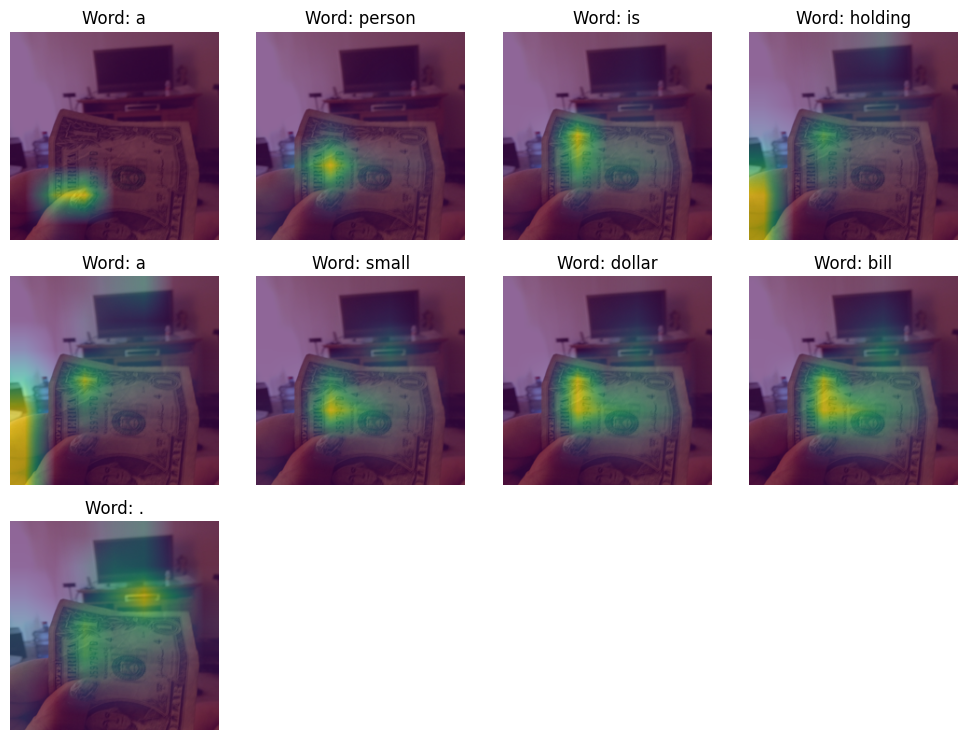

Ground Truth References:
  1. a paper currency note of united state of America one dollar
  2. A one dollar us bill held by a person with painted nails.
  3. one United States of America dollar paper currency
  4. A woman with decoratively painted fingernails holds a one dollar bill in her left hand with her TV and entertainment center visible in the background.
  5. a woman's hand holding a dollar bill with TV stand in background

--- [Model 2 Check] VizWiz_val_00001635.jpg ---
Predicted: A box of frozen food with a picture of a food ..


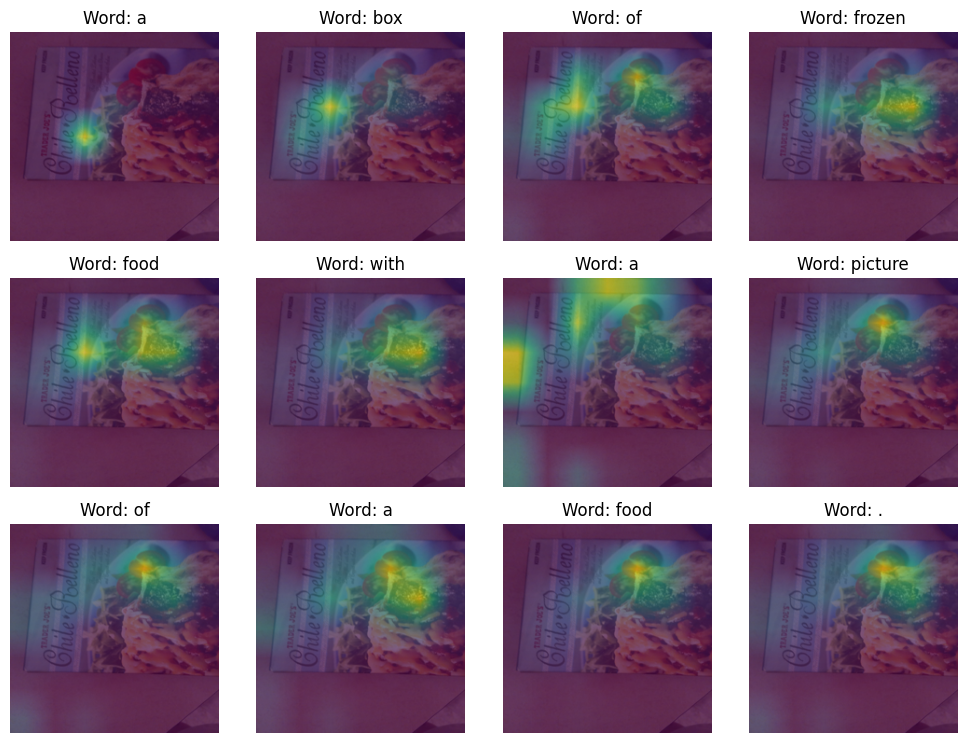

Ground Truth References:
  1. A box of Trader Joe's relleno resting at the verge of a table.
  2. An sideways rotated Chille Beller peppers flat upside front on an table counter.
  3. A light blue box of Trader Joe's Chile Relleno placed on a beige table top with a picture of product in the front.
  4. recipe for Chile from Trader Joe's store, with lots of cheese.
  5. A light grey box with green lettuce and red tomatoes


In [24]:
def visualize_attention(model, df, vocab, num_samples=2):
    """
    Generates a caption and visualizes the attention heatmap for each predicted word.
    """
    model.eval()
    grouped = df.groupby('file_name')
    sample_files = random.sample(list(grouped.groups.keys()), num_samples)

    for file_name in sample_files:
        img_path = CFG.VAL_IMG_DIR / file_name
        img_raw = Image.open(img_path).convert("RGB")
        img_tensor = transform_pipeline(img_raw)
        
        # 1. Generate Caption and Attention Weights
        words, alphas = generate_caption_with_attention(model, img_tensor, vocab)
        
        print(f"\n--- [Model 2 Check] {file_name} ---")
        print(f"\033[1mPredicted: \033[94m{' '.join(words).capitalize()}.\033[0m")
        
        # 2. Plotting the Attention "Focus" per word
        num_words = len(words)
        cols = 4
        rows = (num_words // cols) + 1
        
        fig = plt.figure(figsize=(10, rows * 2.5), dpi=100)
        
        for i, word in enumerate(words):
            # Upscale 7x7 attention map to original image size
            alpha_map = alphas[i].reshape(7, 7)
            alpha_img = Image.fromarray(alpha_map).resize((224, 224), resample=Image.BILINEAR)
            
            ax = fig.add_subplot(rows, cols, i + 1)
            ax.set_title(f"Word: {word}")
            ax.imshow(img_raw.resize((224, 224)))
            # Overlay the heatmap
            ax.imshow(np.array(alpha_img), alpha=0.6, cmap='viridis')
            ax.axis('off')
            
        plt.tight_layout()
        plt.show()
        
        print("Ground Truth References:")
        for i, (_, row) in enumerate(grouped.get_group(file_name).iterrows(), 1):
            print(f"  {i}. {row['caption']}")
        print("="*60)

# Run Visual Inspection
if CFG.SHOW_MODEL_PLOTS:
    visualize_attention(model_v2, val_df, vocab, num_samples=2)